In [1]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from statsmodels.genmod.families import NegativeBinomial
from scipy.special import logit, expit
import pandas as pd
# plt.style.use('ggplot')

In [2]:
analysis_data_dir = r"../../Data/AnalysisData/sensitivity_analysis_data.csv"
df_overall_model = pd.read_csv(analysis_data_dir)
df_overall_model["TEMPORAL_MASKING_FN_TYPE_ONE_HOT"] = [1 if i=="full" else 0 for i in df_overall_model["TEMPORAL_MASKING_FN_TYPE"]]
df_overall_model.to_csv("sensitivity_analysis_data_for_R.csv")
df_overall_model["identifier"] = "treatment"

time_keys = ["CALL_DURATION", "TIME_DELAY_FOR_DIRECTION_CHANGE", "BAT_RADIAL_RESOLUTION"]
df_overall_model[time_keys] = df_overall_model[time_keys]*1000 # to make seconds into ms

labels = np.array(['bat speed', 'call duration', 'fast call rate', 'hearing threshold', 'call directionality', 'temporal masking function', 'time spent listening', 'distance resolution', 'memory window size', 'frontal range'])


In [3]:
def center_df(df):
    centered_df=(df-df.mean())/df.std()
    return centered_df

In [4]:
varying_params = np.array([
    "BAT_SPEED",
    "CALL_DURATION",
    "CALL_RATE_FAST",
    "HEARING_THRESHOLD",
    "CALL_DIRECTIONALITY",
    "TEMPORAL_MASKING_FN_TYPE",
    "TIME_DELAY_FOR_DIRECTION_CHANGE",
    "BAT_RADIAL_RESOLUTION",
    "MEMORY_WINDOW_FOR_CONSISTENCY",
    "BAT_FRONTAL_RANGE",
])
df_overall_model["TEMPORAL_MASKING_FN_TYPE_ONE_HOT"] = [1 if i=="full" else 0 for i in df_overall_model["TEMPORAL_MASKING_FN_TYPE"]] 

In [5]:
import statsmodels.formula.api as smf
from statsmodels.genmod.families import NegativeBinomial
import pandas as pd
from patsy.contrasts import Treatment
# Convert all predictors to categorical (one-hot encoding)
predictors = varying_params
df_cat = df_overall_model.copy()
for col in predictors:
    df_cat[col] = pd.Categorical(df_cat[col])

formula = """
collision_counts ~ C(BAT_SPEED, Treatment(reference=3)) + C(CALL_DURATION) + C(CALL_RATE_FAST) +
C(HEARING_THRESHOLD, Treatment(reference=60)) + C(CALL_DIRECTIONALITY) +
C(TEMPORAL_MASKING_FN_TYPE) + C(TIME_DELAY_FOR_DIRECTION_CHANGE, Treatment(reference=12.0)) +
C(BAT_RADIAL_RESOLUTION) + C(MEMORY_WINDOW_FOR_CONSISTENCY, Treatment(reference=5)) + C(BAT_FRONTAL_RANGE, Treatment(reference=60))
"""

# First fit Poisson to estimate dispersion
poisson_model = smf.glm(formula=formula, data=df_cat, family=sm.families.Poisson()).fit()
pearson_resid = poisson_model.resid_pearson
dispersion = np.sum(pearson_resid**2) / poisson_model.df_resid
alpha = 1/dispersion

# Fit Negative Binomial with categorical variables
model_nb = smf.glm(
    formula=formula,
    data=df_cat,
    family=NegativeBinomial(alpha=alpha),
    # contrasts=contrast_code
).fit()

# Print summary
print("NEGATIVE BINOMIAL MODEL (COLLISION COUNTS - ALL CATEGORICAL)")
print(model_nb.summary2())
print(f"\nFinal alpha parameter: {model_nb.family.alpha:.4f}")

NEGATIVE BINOMIAL MODEL (COLLISION COUNTS - ALL CATEGORICAL)
                                           Results: Generalized linear model
Model:                                 GLM                               AIC:                             832734.5708  
Link Function:                         Log                               BIC:                             -1704339.5183
Dependent Variable:                    collision_counts                  Log-Likelihood:                  -4.1635e+05  
Date:                                  2026-03-13 04:52                  LL-Null:                         -5.4389e+05  
No. Observations:                      155520                            Deviance:                        1.5464e+05   
Df Model:                              15                                Pearson chi2:                    1.85e+05     
Df Residuals:                          155504                            Scale:                           1.0000       
Method:               

In [6]:
model_nb.summary().tables[1]

,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,1.5414,0.008,201.551,0.000,1.526,1.556
"C(BAT_SPEED, Treatment(reference=3))[T.1]",-1.7600,0.006,-318.395,0.000,-1.771,-1.749
"C(BAT_SPEED, Treatment(reference=3))[T.5]",0.7385,0.004,175.614,0.000,0.730,0.747
C(CALL_DURATION)[T.5.0],0.0956,0.004,25.078,0.000,0.088,0.103
C(CALL_RATE_FAST)[T.20],-0.1428,0.004,-37.441,0.000,-0.150,-0.135
"C(HEARING_THRESHOLD, Treatment(reference=60))[T.40]",0.4610,0.005,97.137,0.000,0.452,0.470
"C(HEARING_THRESHOLD, Treatment(reference=60))[T.80]",0.5098,0.005,107.730,0.000,0.501,0.519
C(CALL_DIRECTIONALITY)[T.10],0.0311,0.004,8.150,0.000,0.024,0.039
C(TEMPORAL_MASKING_FN_TYPE)[T.full],0.0034,0.004,0.881,0.378,-0.004,0.011
"C(TIME_DELAY_FOR_DIRECTION_CHANGE, Treatment(reference=12.0))[T.6.0]",0.4633,0.005,99.986,0.000,0.454,0.472


In [7]:
df_cat['space_occupied_norm'] = df_cat['space_occupied'] / np.max(df_cat["space_occupied"])  # Normalized space
df_cat['space_occupied_N'] = np.max(df_cat["space_occupied"]) # maximum of space occupied

In [8]:
formula_bb_cat = """
space_occupied_norm ~ C(BAT_SPEED, Treatment(reference=3)) + C(CALL_DURATION) + C(CALL_RATE_FAST) +
C(HEARING_THRESHOLD, Treatment(reference=60)) + C(CALL_DIRECTIONALITY) +
C(TEMPORAL_MASKING_FN_TYPE) + C(TIME_DELAY_FOR_DIRECTION_CHANGE, Treatment(reference=12.0)) +
C(BAT_RADIAL_RESOLUTION) + C(MEMORY_WINDOW_FOR_CONSISTENCY, Treatment(reference=5)) + C(BAT_FRONTAL_RANGE, Treatment(reference=60))
"""

# Refit model
model_bb = smf.glm(
    formula=formula_bb_cat,
    data=df_cat,
    family=sm.families.Binomial(),
    var_weights=df_cat['space_occupied_N']
).fit()

model_bb.summary2()


<class 'statsmodels.iolib.summary2.Summary'>
"""
                                           Results: Generalized linear model
========================================================================================================================
Model:                               GLM                                  AIC:                             35646332.0142
Link Function:                       Logit                                BIC:                             -893137.1287 
Dependent Variable:                  space_occupied_norm                  Log-Likelihood:                  -1.7823e+07  
Date:                                2026-03-13 04:52                     LL-Null:                         -2.2132e+07  
No. Observations:                    155520                               Deviance:                        9.6584e+05   
Df Model:                            15                                   Pearson chi2:                    9.78e+05     
Df Residuals:                        155504                               Scale:                           1.0000       
Method:                              IRLS                                                                               
------------------------------------------------------------------------------------------------------------------------
                                                                       Coef.  Std.Err.     z      P>|z|   [0.025  0.975]
------------------------------------------------------------------------------------------------------------------------
Intercept                                                             -0.1877   0.0013  -143.6836 0.0000 -0.1903 -0.1852
C(BAT_SPEED, Treatment(reference=3))[T.1]                             -1.4047   0.0009 -1638.4223 0.0000 -1.4064 -1.4030
C(BAT_SPEED, Treatment(reference=3))[T.5]                              0.8334   0.0008  1086.5744 0.0000  0.8318  0.8349
C(CALL_DURATION)[T.5.0]                                                0.0956   0.0007   143.7008 0.0000  0.0943  0.0969
C(CALL_RATE_FAST)[T.20]                                               -0.0237   0.0007   -35.7010 0.0000 -0.0250 -0.0224
C(HEARING_THRESHOLD, Treatment(reference=60))[T.40]                   -0.4929   0.0008  -600.9159 0.0000 -0.4945 -0.4913
C(HEARING_THRESHOLD, Treatment(reference=60))[T.80]                    0.2621   0.0008   324.3409 0.0000  0.2605  0.2637
C(CALL_DIRECTIONALITY)[T.10]                                           0.0263   0.0007    39.5586 0.0000  0.0250  0.0276
C(TEMPORAL_MASKING_FN_TYPE)[T.full]                                   -0.0001   0.0007    -0.2184 0.8271 -0.0014  0.0012
C(TIME_DELAY_FOR_DIRECTION_CHANGE, Treatment(reference=12.0))[T.6.0]   0.2353   0.0008   289.2119 0.0000  0.2337  0.2369
C(TIME_DELAY_FOR_DIRECTION_CHANGE, Treatment(reference=12.0))[T.24.0] -0.0558   0.0008   -68.4120 0.0000 -0.0574 -0.0542
C(BAT_RADIAL_RESOLUTION)[T.4.0]                                       -0.0278   0.0007   -41.8743 0.0000 -0.0291 -0.0265
C(MEMORY_WINDOW_FOR_CONSISTENCY, Treatment(reference=5))[T.3]          0.0557   0.0008    68.3506 0.0000  0.0541  0.0573
C(MEMORY_WINDOW_FOR_CONSISTENCY, Treatment(reference=5))[T.10]         0.0623   0.0008    76.4568 0.0000  0.0607  0.0639
C(BAT_FRONTAL_RANGE, Treatment(reference=60))[T.30]                    0.0743   0.0008    91.3014 0.0000  0.0727  0.0759
C(BAT_FRONTAL_RANGE, Treatment(reference=60))[T.90]                   -0.0555   0.0008   -68.0724 0.0000 -0.0571 -0.0539
========================================================================================================================

"""

In [9]:
dict_values = pd.DataFrame()
dict_values["label"] = model_bb.params.keys()
dict_values["irr"] = np.exp(model_bb.params.values)
dict_values["coeff"] = model_bb.params.values

# d = model_bb.params
# df["irr"] = np.exp(model_bb.params.values)
# df
dict_values

,label,irr,coeff
0,Intercept,0.828834,-0.187735
1,"C(BAT_SPEED, Treatment(reference=3))[T.1]",0.245437,-1.404714
2,"C(BAT_SPEED, Treatment(reference=3))[T.5]",2.301019,0.833352
3,C(CALL_DURATION)[T.5.0],1.100281,0.095566
4,C(CALL_RATE_FAST)[T.20],0.976541,-0.023739
5,"C(HEARING_THRESHOLD, Treatment(reference=60))[...",0.610868,-0.492875
6,"C(HEARING_THRESHOLD, Treatment(reference=60))[...",1.299658,0.262101
7,C(CALL_DIRECTIONALITY)[T.10],1.026653,0.026304
8,C(TEMPORAL_MASKING_FN_TYPE)[T.full],0.999855,-0.000145
9,"C(TIME_DELAY_FOR_DIRECTION_CHANGE, Treatment(r...",1.265305,0.235313


In [10]:
model_bb.params.keys()

Index(['Intercept', 'C(BAT_SPEED, Treatment(reference=3))[T.1]',
       'C(BAT_SPEED, Treatment(reference=3))[T.5]', 'C(CALL_DURATION)[T.5.0]',
       'C(CALL_RATE_FAST)[T.20]',
       'C(HEARING_THRESHOLD, Treatment(reference=60))[T.40]',
       'C(HEARING_THRESHOLD, Treatment(reference=60))[T.80]',
       'C(CALL_DIRECTIONALITY)[T.10]', 'C(TEMPORAL_MASKING_FN_TYPE)[T.full]',
       'C(TIME_DELAY_FOR_DIRECTION_CHANGE, Treatment(reference=12.0))[T.6.0]',
       'C(TIME_DELAY_FOR_DIRECTION_CHANGE, Treatment(reference=12.0))[T.24.0]',
       'C(BAT_RADIAL_RESOLUTION)[T.4.0]',
       'C(MEMORY_WINDOW_FOR_CONSISTENCY, Treatment(reference=5))[T.3]',
       'C(MEMORY_WINDOW_FOR_CONSISTENCY, Treatment(reference=5))[T.10]',
       'C(BAT_FRONTAL_RANGE, Treatment(reference=60))[T.30]',
       'C(BAT_FRONTAL_RANGE, Treatment(reference=60))[T.90]'],
      dtype='object')

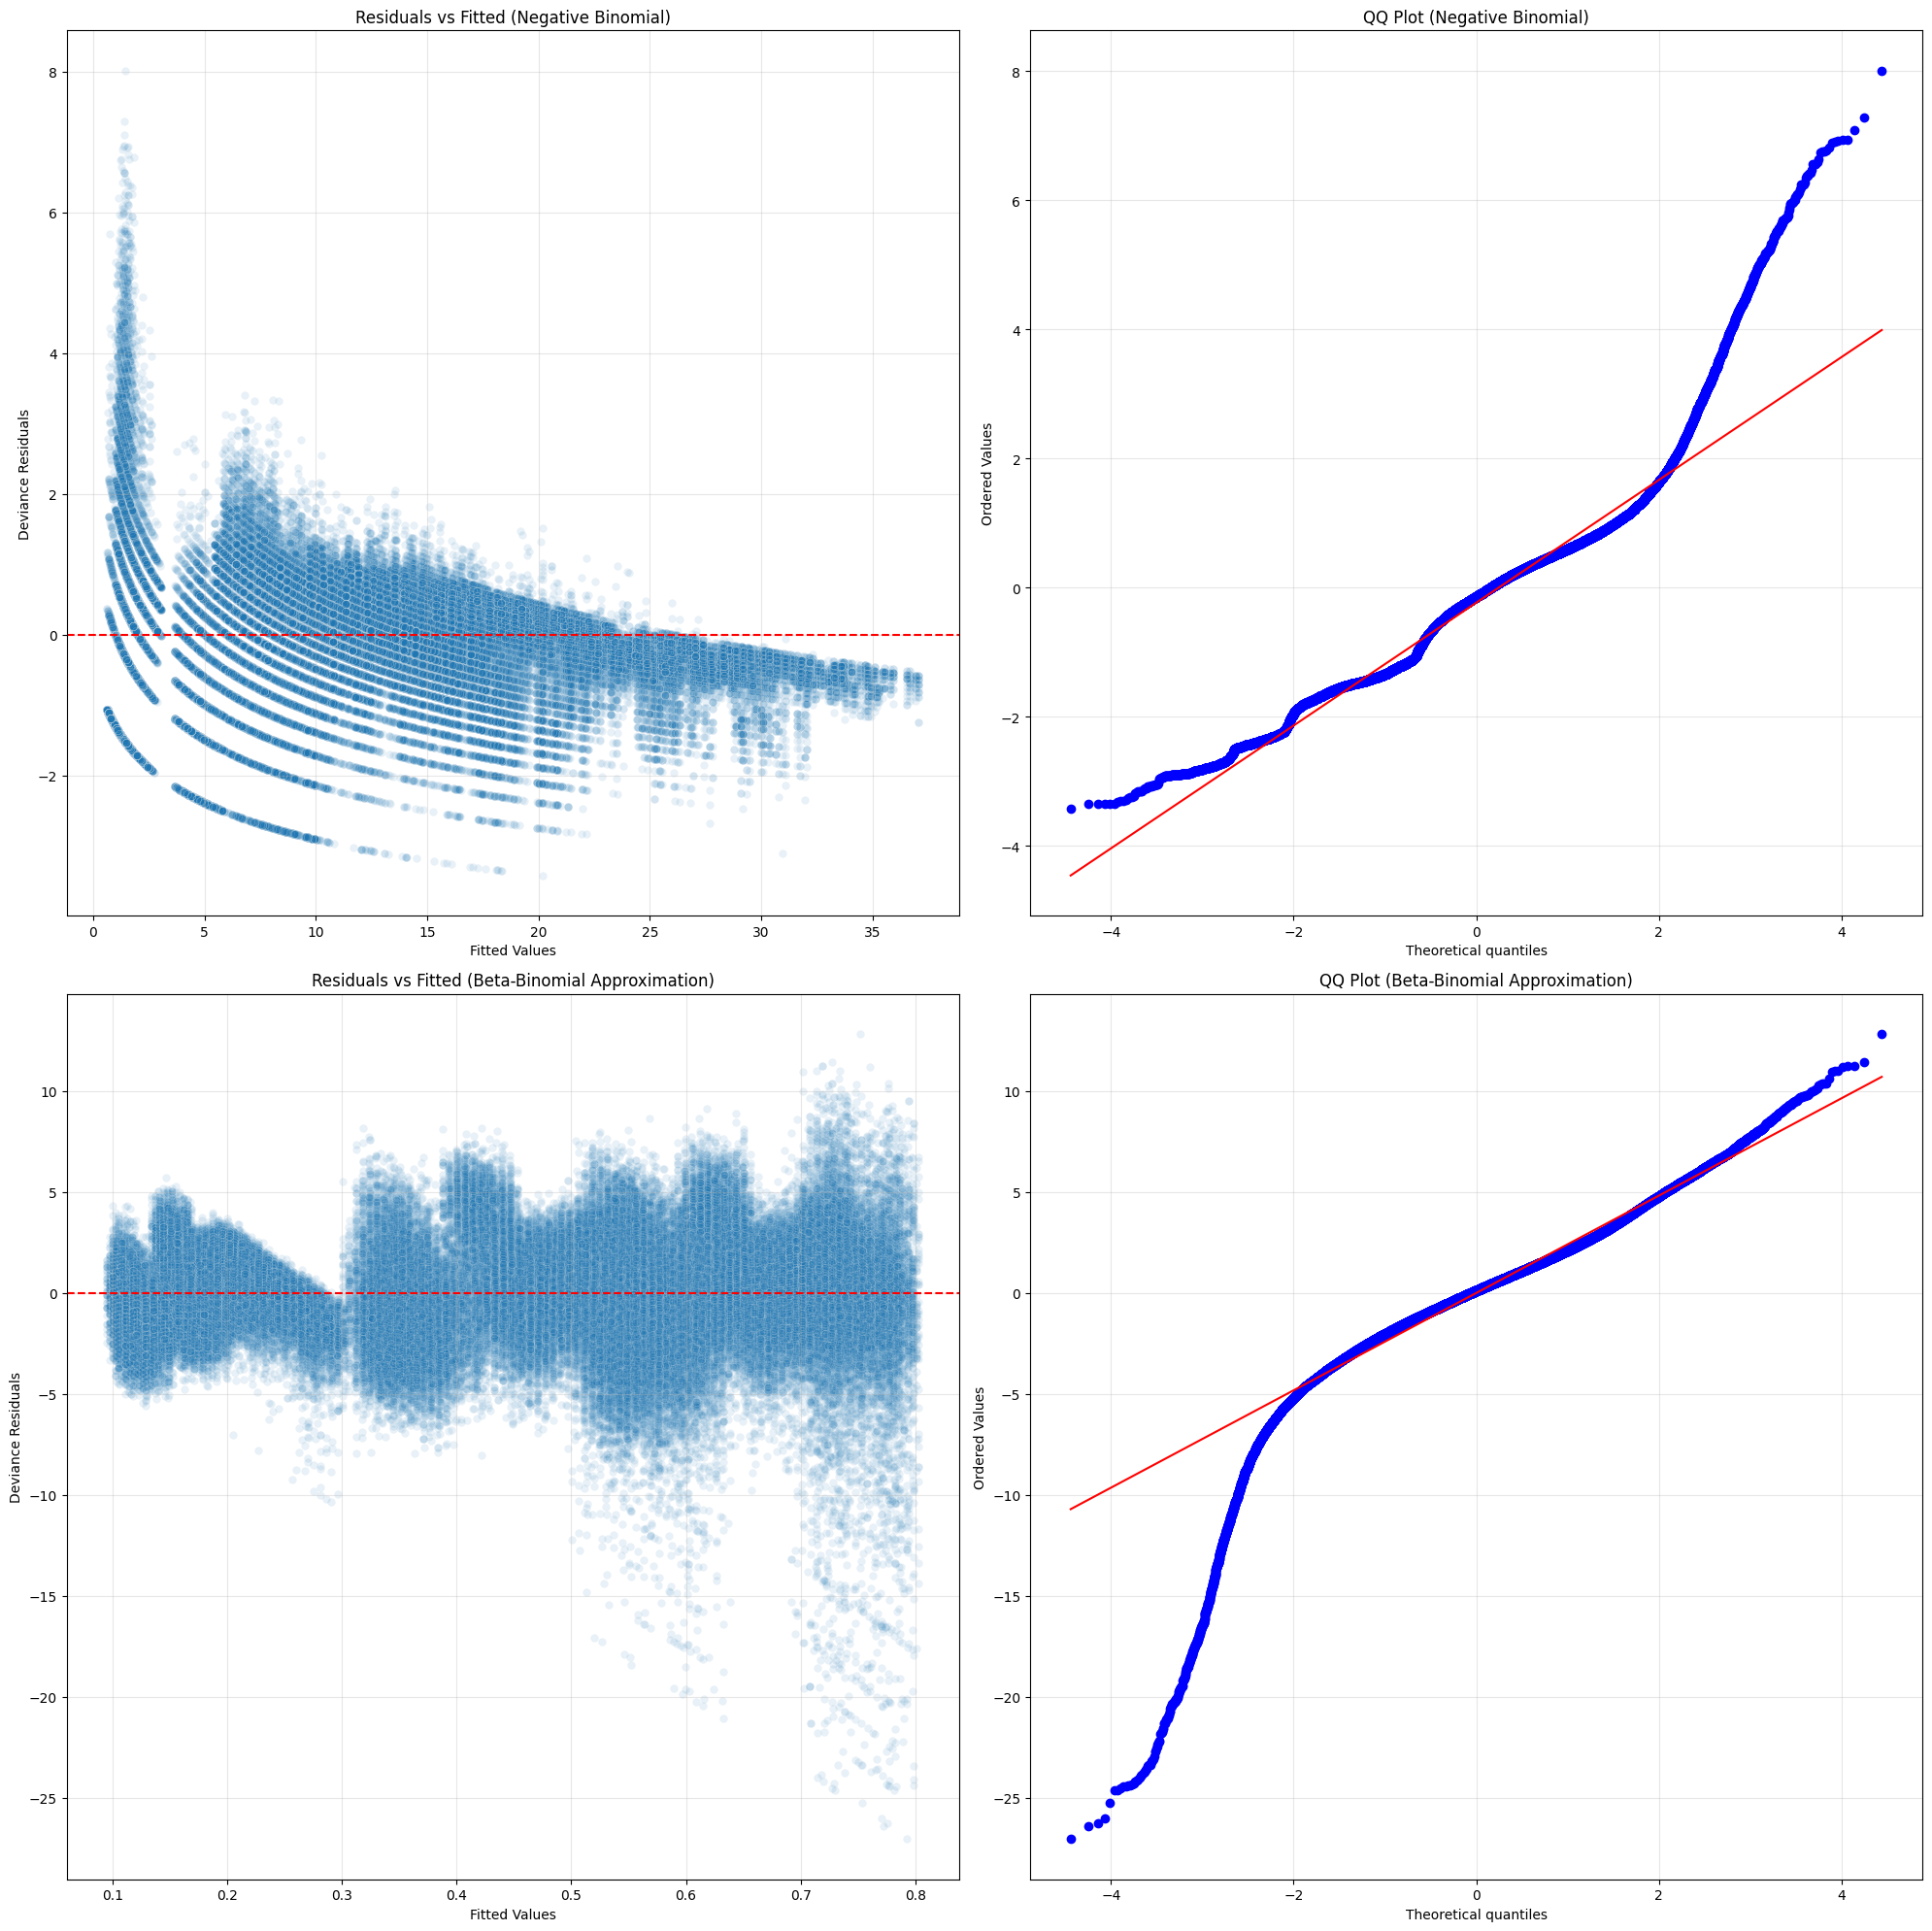

In [17]:
plt.figure(figsize=(20,20))
plt.subplot(2,2,1)
sns.scatterplot(x=model_nb.fittedvalues, y=model_nb.resid_deviance, alpha=0.1)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Deviance Residuals")
plt.title("Residuals vs Fitted (Negative Binomial)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.tight_layout()
# plt.show()

# QQ Plot
plt.subplot(2,2,2)
stats.probplot(model_nb.resid_deviance, dist="norm", plot=plt)
plt.title("QQ Plot (Negative Binomial)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.tight_layout()
# plt.show()

plt.subplot(2,2,3)
sns.scatterplot(x=model_bb.fittedvalues, y=model_bb.resid_deviance, alpha=0.1)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Deviance Residuals")
plt.title("Residuals vs Fitted (Beta-Binomial Approximation)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.tight_layout()
# plt.show()

# QQ Plot
plt.subplot(2,2,4)
stats.probplot(model_bb.resid_deviance, dist="norm", plot=plt)
plt.title("QQ Plot (Beta-Binomial Approximation)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.tight_layout()
# plt.show()

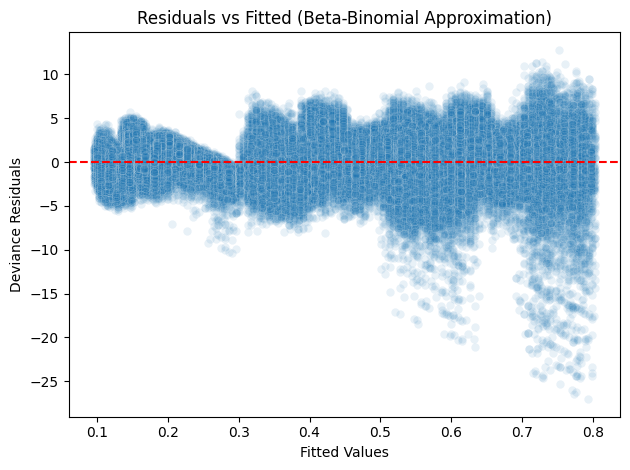

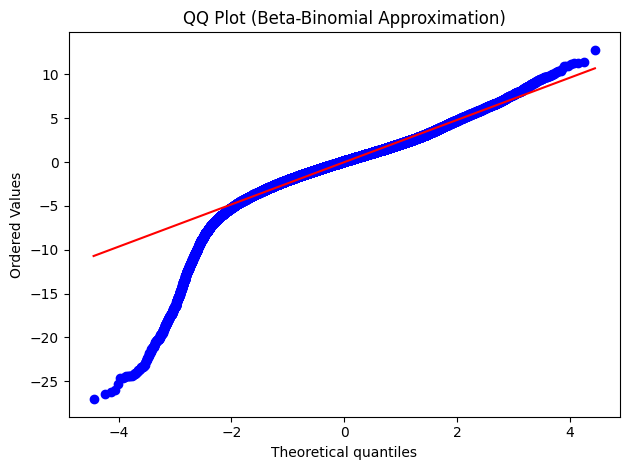

In [12]:
plt.figure()
sns.scatterplot(x=model_bb.fittedvalues, y=model_bb.resid_deviance, alpha=0.1)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Deviance Residuals")
plt.title("Residuals vs Fitted (Beta-Binomial Approximation)")
plt.tight_layout()
plt.show()

# QQ Plot
plt.figure()
stats.probplot(model_bb.resid_deviance, dist="norm", plot=plt)
plt.title("QQ Plot (Beta-Binomial Approximation)")
plt.tight_layout()
plt.show()



In [13]:
results = model_nb.summary2().tables[1]
categorical_params = [p for p in results.index if '[' in p]
print(categorical_params)
# Create a plot for each parameter
baseline_df = pd.DataFrame()
baseline_df["parameter"] = varying_params
baseline_df["odds_ratio"] = [1] * len(varying_params)
baseline_df["parameter_value"] = [3, 2, 10, 60, 7, "chopped", 12.0, 2.0, 5, 60]
baseline_df["ci_low"] = [1] * len(varying_params)
baseline_df["ci_high"] = [1] * len(varying_params)

parameter_list = []
parameter_value_list = []
odds_ratio_list = []
ci_low_list = []
ci_high_list = []

for param in categorical_params:
    # Extract base parameter name and category
    base_param = param.split(',')[0].split(")")[0][2:]
    # base_param = param.split('[')[0]
    category = param.split('[')[1].split(']')[0].replace('T.', '')
    if category!="full":
        category = float(category)
    # print(category)
    
    or_val = np.exp(results.loc[param, 'Coef.'])
    ci_low = np.exp(results.loc[param, '[0.025'])
    ci_high = np.exp(results.loc[param, '0.975]'])
    
    parameter_value_list.append(category)
    parameter_list.append(base_param)
    odds_ratio_list.append(or_val)
    ci_low_list.append(ci_low)
    ci_high_list.append(ci_high)
    
new_df = pd.DataFrame()
new_df["parameter"] = parameter_list
new_df["odds_ratio"] = odds_ratio_list
new_df["parameter_value"] = parameter_value_list
new_df["ci_low"] = ci_low_list
new_df["ci_high"] = ci_high_list
condensed_nb_df = pd.concat((baseline_df,new_df)).reset_index()
condensed_nb_df

['C(BAT_SPEED, Treatment(reference=3))[T.1]', 'C(BAT_SPEED, Treatment(reference=3))[T.5]', 'C(CALL_DURATION)[T.5.0]', 'C(CALL_RATE_FAST)[T.20]', 'C(HEARING_THRESHOLD, Treatment(reference=60))[T.40]', 'C(HEARING_THRESHOLD, Treatment(reference=60))[T.80]', 'C(CALL_DIRECTIONALITY)[T.10]', 'C(TEMPORAL_MASKING_FN_TYPE)[T.full]', 'C(TIME_DELAY_FOR_DIRECTION_CHANGE, Treatment(reference=12.0))[T.6.0]', 'C(TIME_DELAY_FOR_DIRECTION_CHANGE, Treatment(reference=12.0))[T.24.0]', 'C(BAT_RADIAL_RESOLUTION)[T.4.0]', 'C(MEMORY_WINDOW_FOR_CONSISTENCY, Treatment(reference=5))[T.3]', 'C(MEMORY_WINDOW_FOR_CONSISTENCY, Treatment(reference=5))[T.10]', 'C(BAT_FRONTAL_RANGE, Treatment(reference=60))[T.30]', 'C(BAT_FRONTAL_RANGE, Treatment(reference=60))[T.90]']


,index,parameter,odds_ratio,parameter_value,ci_low,ci_high
0,0,BAT_SPEED,1.000000,3,1.000000,1.000000
1,1,CALL_DURATION,1.000000,2,1.000000,1.000000
2,2,CALL_RATE_FAST,1.000000,10,1.000000,1.000000
3,3,HEARING_THRESHOLD,1.000000,60,1.000000,1.000000
4,4,CALL_DIRECTIONALITY,1.000000,7,1.000000,1.000000
5,5,TEMPORAL_MASKING_FN_TYPE,1.000000,chopped,1.000000,1.000000
6,6,TIME_DELAY_FOR_DIRECTION_CHANGE,1.000000,12.0,1.000000,1.000000
7,7,BAT_RADIAL_RESOLUTION,1.000000,2.0,1.000000,1.000000
8,8,MEMORY_WINDOW_FOR_CONSISTENCY,1.000000,5,1.000000,1.000000
9,9,BAT_FRONTAL_RANGE,1.000000,60,1.000000,1.000000


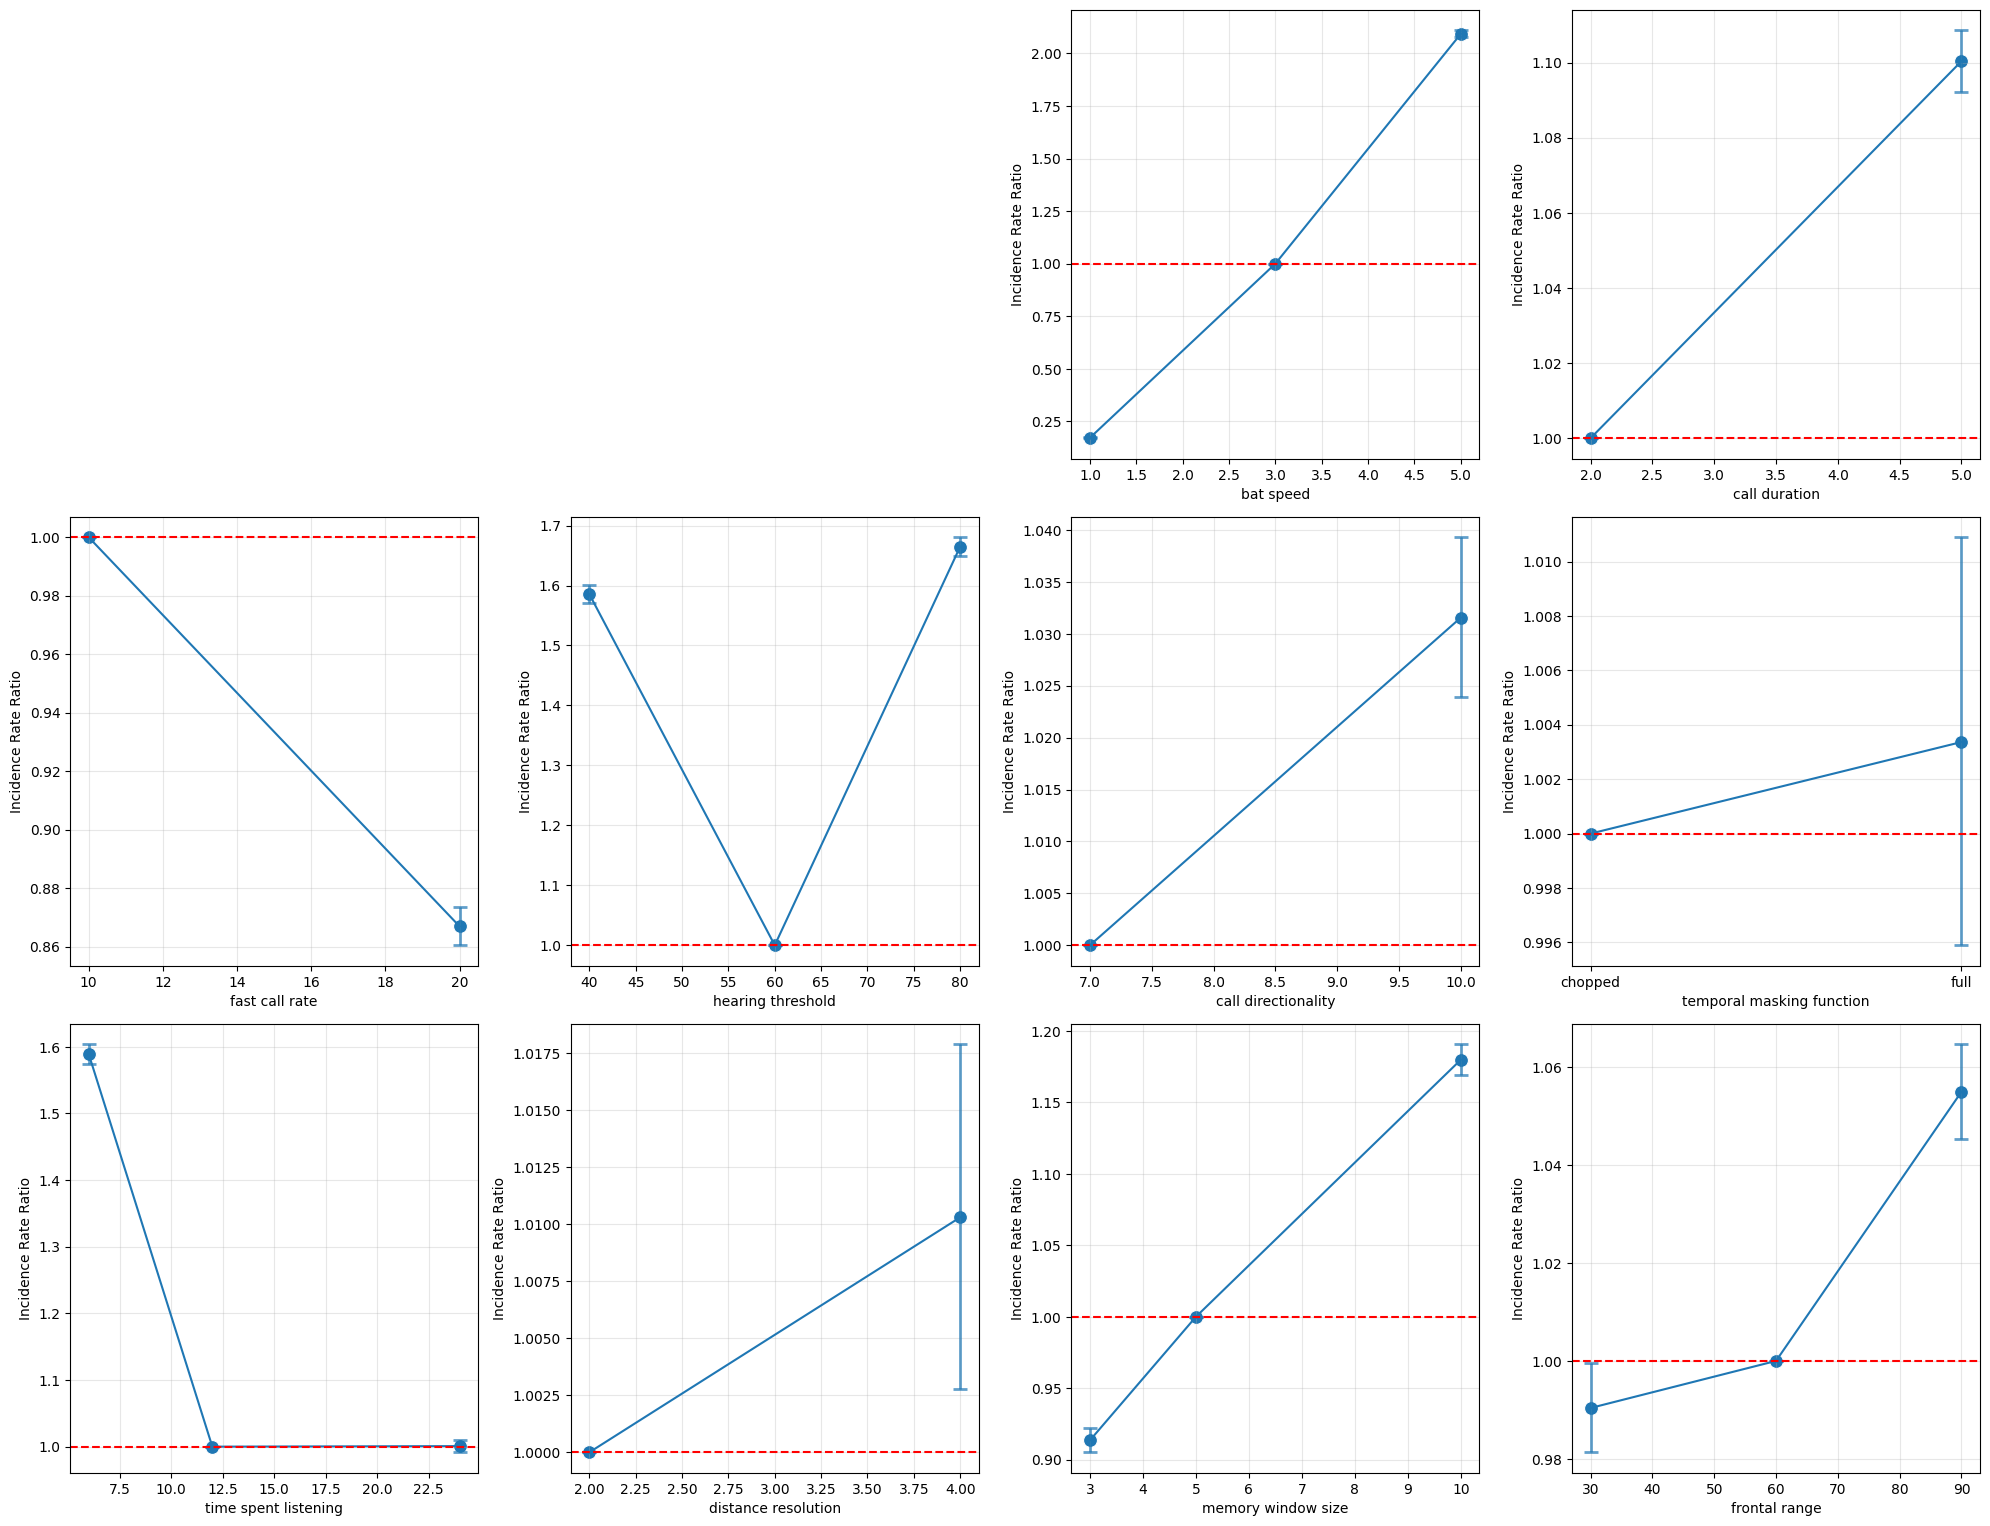

[0    0.000000
1    0.009048
2    0.009596
dtype: float64, 0    0.000000
1    0.009131
2    0.009684
dtype: float64]


In [14]:
plt.figure(figsize=(20, 20))
for i, param in enumerate(varying_params):
    subset_df = condensed_nb_df.groupby("parameter").get_group(param).reset_index()
    
    y_vals= subset_df['odds_ratio']
    x_vals= subset_df['parameter_value']
    lower = subset_df['ci_low']
    upper = subset_df['ci_high']
    lower_error = y_vals - lower
    upper_error = upper - y_vals
    
    errors = [lower_error, upper_error]
    plt.subplot(4,4,i+3)
    ax = sns.lineplot(x=subset_df['parameter_value'], y=subset_df['odds_ratio'], ls='-')  # Black line with dots
    sns.scatterplot(x=subset_df['parameter_value'], y=subset_df['odds_ratio'], s=100)
    
    plt.errorbar(x_vals, y_vals, yerr=errors,fmt='none',capsize=5,capthick=2, alpha=0.7,elinewidth=2
    )
    plt.axhline(1, color='red', linestyle='--')
    plt.xlabel(labels[i])
    plt.ylabel('Incidence Rate Ratio')

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    # plt.ylim(0.2,2.5)
# plt.suptitle("Space occupied, Odds ratios of Binomial fit")
plt.show()
print(errors)

In [15]:
results = model_bb.summary2().tables[1]
categorical_params = [p for p in results.index if '[' in p]
print(categorical_params)
# Create a plot for each parameter
baseline_df = pd.DataFrame()
baseline_df["parameter"] = varying_params
baseline_df["odds_ratio"] = [1] * len(varying_params)
baseline_df["parameter_value"] = [3, 2, 10, 60, 7, "chopped", 12.0, 2.0, 5, 60]
baseline_df["ci_low"] = [1] * len(varying_params)
baseline_df["ci_high"] = [1] * len(varying_params)

parameter_list = []
parameter_value_list = []
odds_ratio_list = []
ci_low_list = []
ci_high_list = []

for param in categorical_params:
    # Extract base parameter name and category
    base_param = param.split(',')[0].split(")")[0][2:]
    # base_param = param.split('[')[0]
    category = param.split('[')[1].split(']')[0].replace('T.', '')
    if category!="full":
        category = float(category)
    # print(category)
    
    or_val = np.exp(results.loc[param, 'Coef.'])
    ci_low = np.exp(results.loc[param, '[0.025'])
    ci_high = np.exp(results.loc[param, '0.975]'])
    
    parameter_value_list.append(category)
    parameter_list.append(base_param)
    odds_ratio_list.append(or_val)
    ci_low_list.append(ci_low)
    ci_high_list.append(ci_high)
    
new_df = pd.DataFrame()
new_df["parameter"] = parameter_list
new_df["odds_ratio"] = odds_ratio_list
new_df["parameter_value"] = parameter_value_list
new_df["ci_low"] = ci_low_list
new_df["ci_high"] = ci_high_list
condensed_bb_df = pd.concat((baseline_df,new_df)).reset_index()
condensed_bb_df

['C(BAT_SPEED, Treatment(reference=3))[T.1]', 'C(BAT_SPEED, Treatment(reference=3))[T.5]', 'C(CALL_DURATION)[T.5.0]', 'C(CALL_RATE_FAST)[T.20]', 'C(HEARING_THRESHOLD, Treatment(reference=60))[T.40]', 'C(HEARING_THRESHOLD, Treatment(reference=60))[T.80]', 'C(CALL_DIRECTIONALITY)[T.10]', 'C(TEMPORAL_MASKING_FN_TYPE)[T.full]', 'C(TIME_DELAY_FOR_DIRECTION_CHANGE, Treatment(reference=12.0))[T.6.0]', 'C(TIME_DELAY_FOR_DIRECTION_CHANGE, Treatment(reference=12.0))[T.24.0]', 'C(BAT_RADIAL_RESOLUTION)[T.4.0]', 'C(MEMORY_WINDOW_FOR_CONSISTENCY, Treatment(reference=5))[T.3]', 'C(MEMORY_WINDOW_FOR_CONSISTENCY, Treatment(reference=5))[T.10]', 'C(BAT_FRONTAL_RANGE, Treatment(reference=60))[T.30]', 'C(BAT_FRONTAL_RANGE, Treatment(reference=60))[T.90]']


,index,parameter,odds_ratio,parameter_value,ci_low,ci_high
0,0,BAT_SPEED,1.000000,3,1.000000,1.000000
1,1,CALL_DURATION,1.000000,2,1.000000,1.000000
2,2,CALL_RATE_FAST,1.000000,10,1.000000,1.000000
3,3,HEARING_THRESHOLD,1.000000,60,1.000000,1.000000
4,4,CALL_DIRECTIONALITY,1.000000,7,1.000000,1.000000
5,5,TEMPORAL_MASKING_FN_TYPE,1.000000,chopped,1.000000,1.000000
6,6,TIME_DELAY_FOR_DIRECTION_CHANGE,1.000000,12.0,1.000000,1.000000
7,7,BAT_RADIAL_RESOLUTION,1.000000,2.0,1.000000,1.000000
8,8,MEMORY_WINDOW_FOR_CONSISTENCY,1.000000,5,1.000000,1.000000
9,9,BAT_FRONTAL_RANGE,1.000000,60,1.000000,1.000000


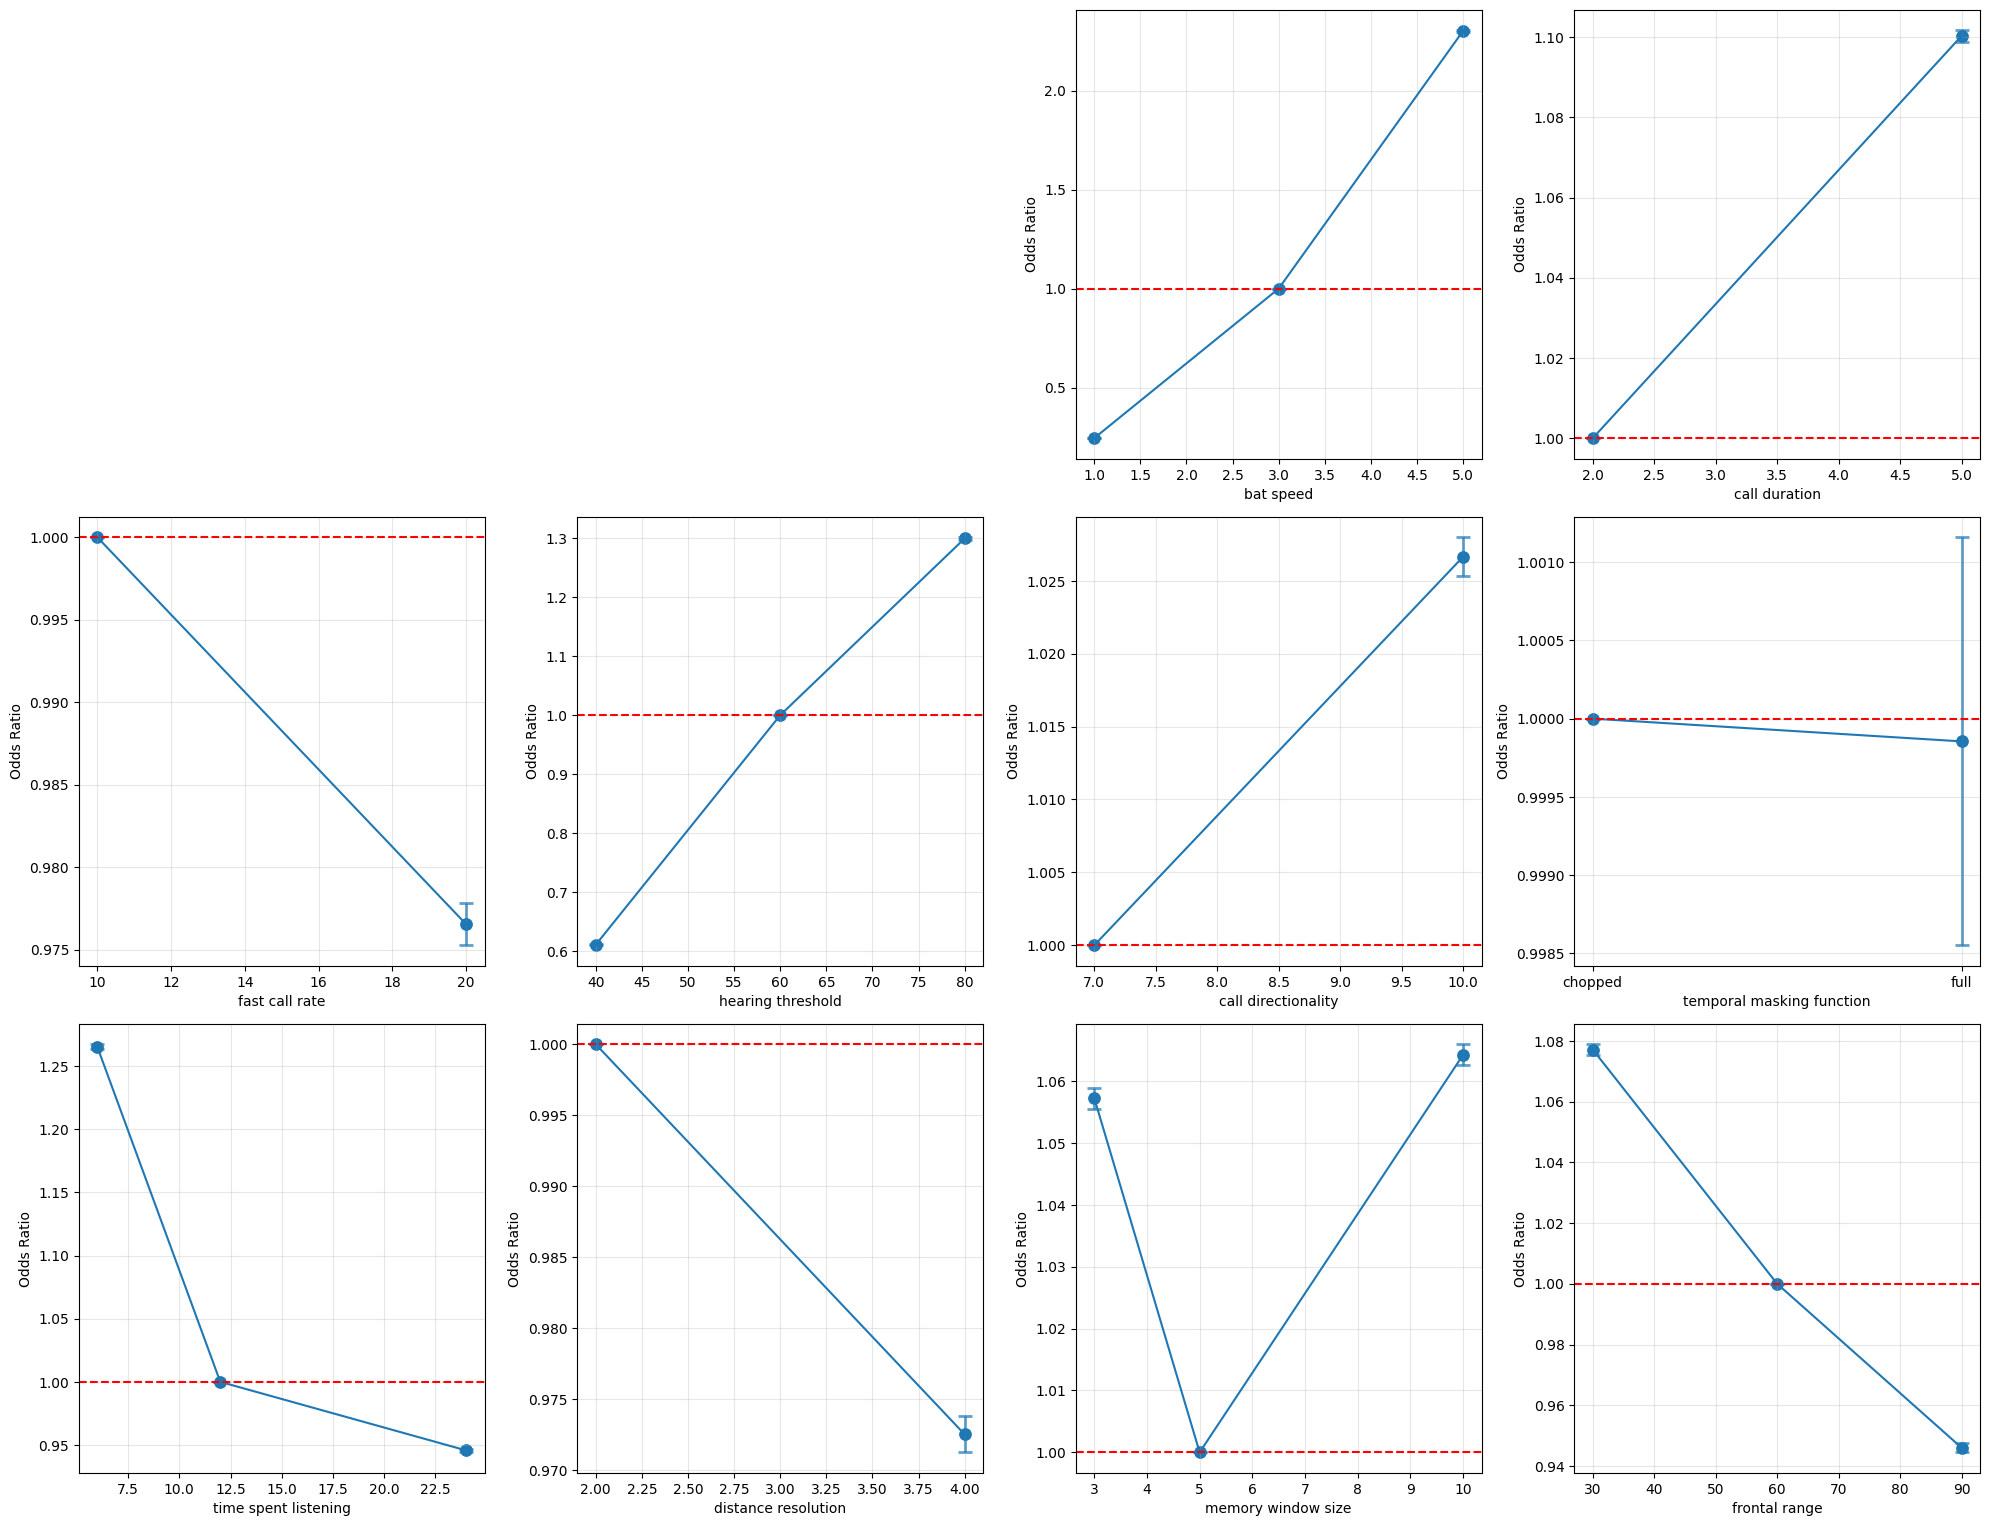

[0    0.000000
1    0.001716
2    0.001510
dtype: float64, 0    0.000000
1    0.001719
2    0.001513
dtype: float64]


In [16]:
plt.figure(figsize=(20, 20))
for i, param in enumerate(varying_params):
    subset_df = condensed_bb_df.groupby("parameter").get_group(param).reset_index()
    
    y_vals= subset_df['odds_ratio']
    x_vals= subset_df['parameter_value']
    lower = subset_df['ci_low']
    upper = subset_df['ci_high']
    lower_error = y_vals - lower
    upper_error = upper - y_vals
    
    errors = [lower_error, upper_error]
    plt.subplot(4,4,i+3)
    ax = sns.lineplot(x=subset_df['parameter_value'], y=subset_df['odds_ratio'], ls='-')  # Black line with dots
    sns.scatterplot(x=subset_df['parameter_value'], y=subset_df['odds_ratio'], s=100)
    
    plt.errorbar(x_vals, y_vals, yerr=errors,fmt='none',capsize=5,capthick=2, alpha=0.7,elinewidth=2
    )
    plt.axhline(1, color='red', linestyle='--')
    plt.xlabel(labels[i])
    plt.ylabel('Odds Ratio')

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    # plt.ylim(0.2,2.5)
# plt.suptitle("Space occupied, Odds ratios of Binomial fit")
plt.show()
print(errors)

x_vals 